# 02 — Model Comparison

Loads the results produced by `src/pipeline.py` (baseline vs XGBoost vs LSTM, regression and classification, ML metrics + backtest). Run `python -m src.pipeline` first if `data/processed/results/` is empty.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.data_loader import load_config

config = load_config()
results_dir = Path.cwd().parent / config["data"]["results_dir"]

comparison_table = pd.read_csv(results_dir / "comparison_table.csv", index_col=0)
predictions = pd.read_csv(results_dir / "predictions.csv", index_col=0, parse_dates=True)
equity_curves = pd.read_csv(results_dir / "equity_curves.csv", index_col=0, parse_dates=True)

comparison_table

,mae,rmse,mape,strategy_cumulative_return,strategy_sharpe_ratio,strategy_max_drawdown,strategy_win_rate,buy_and_hold_cumulative_return,buy_and_hold_sharpe_ratio,buy_and_hold_max_drawdown,buy_and_hold_win_rate,accuracy,f1
baseline_reg,1.066119,1.355923,0.014192,0.000000,0.000000,0.000000,0.000000,-0.090670,-0.235541,-0.24347,0.474886,NaN,NaN
xgboost_reg,1.298257,1.629118,0.017431,-0.103588,-0.432414,-0.222354,0.403509,-0.090670,-0.235541,-0.24347,0.474886,NaN,NaN
lstm_reg,7.130928,8.927641,0.089457,0.178458,2.237745,-0.043080,0.571429,-0.126822,-0.436345,-0.24347,0.480000,NaN,NaN
baseline_clf,NaN,NaN,NaN,-0.090670,-0.235541,-0.243470,0.474886,-0.090670,-0.235541,-0.24347,0.474886,0.474886,0.643963
xgboost_clf,NaN,NaN,NaN,-0.111130,-0.428269,-0.264615,0.406250,-0.090670,-0.235541,-0.24347,0.474886,0.502283,0.591760
lstm_clf,NaN,NaN,NaN,0.050800,0.385775,-0.177464,0.456954,-0.126822,-0.436345,-0.24347,0.480000,0.555000,0.607930


## Predictions vs actual (regression models, test period)

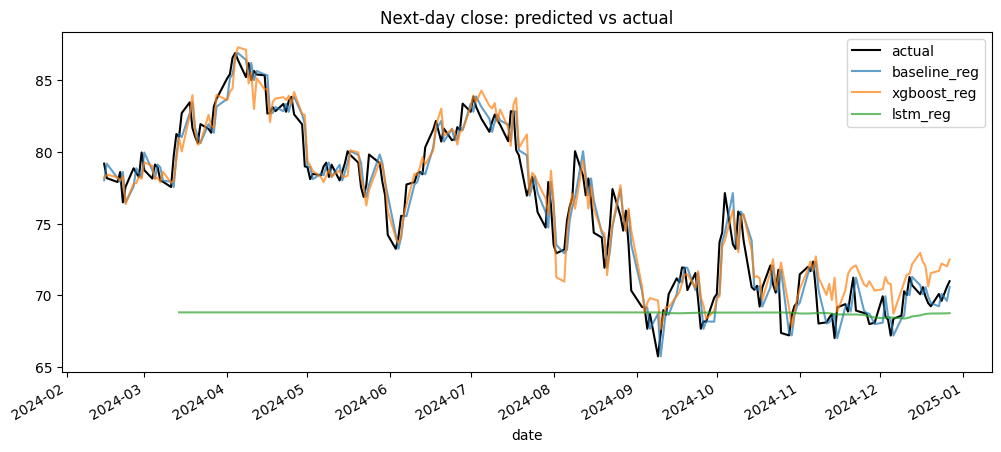

In [2]:
features_df = pd.read_csv(
    Path.cwd().parent / config["data"]["processed_dir"] / "features.csv",
    index_col="date", parse_dates=True,
)
actual = features_df.loc[predictions.index, "target_reg"]

reg_cols = [c for c in predictions.columns if c.endswith("_reg")]
fig, ax = plt.subplots(figsize=(12, 5))
actual.plot(ax=ax, label="actual", color="black", linewidth=1.5)
for col in reg_cols:
    predictions[col].plot(ax=ax, label=col, alpha=0.7)
ax.set_title("Next-day close: predicted vs actual")
ax.legend()
plt.show()

## Backtest equity curves vs buy-and-hold

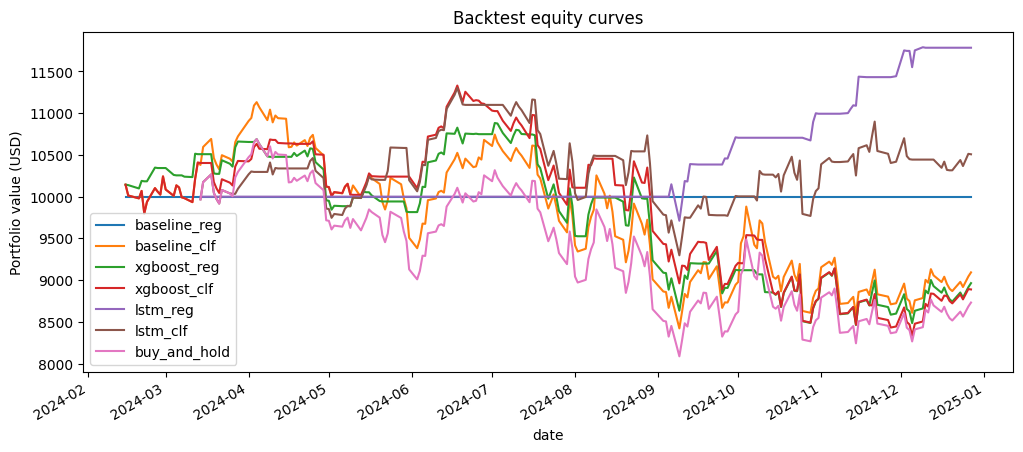

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))
equity_curves.plot(ax=ax)
ax.set_title("Backtest equity curves")
ax.set_ylabel("Portfolio value (USD)")
plt.show()